In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/indicator_CLu")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/indicator_CLu')

In [5]:
df = pd.read_csv("data/feature_engineered_data.csv")

In [6]:
df["indicator_name"].nunique()


42

In [7]:
df.columns

Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country'],
      dtype='object')

In [8]:
indicator_df = (
    df.groupby("indicator_name").agg(
        spike_count=("spike", "sum"),
        dip_count=("dip", "sum"),
        avg_volatility=("rolling_std_5y", "mean"),
        slope_mean=("trend_slope", "mean"),
        momentum_mean=("momentum", "mean"),
        coef_variation=("coef_variation", "mean"),
        cagr_mean=("cagr", "mean"),
        regional_dev_std=("regional_deviation_std", "mean"),
        # event exposure (optional but included)
        global_event_count=("event_global", lambda x: x.notna().sum()),
        country_event_count=("event_country", lambda x: x.notna().sum()),
        # category (interpretation only)
        category=("category", lambda x: x.mode()[0])
    )
).reset_index()



In [9]:
indicator_df.head()

,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean,regional_dev_std,global_event_count,country_event_count,category
0,A woman can apply for a passport in the same w...,7,0,NaN,0.020314,-inf,94.620196,NaN,1.490577e-17,360,61,Other
1,"A woman can be ""head of household"" in the same...",0,4,NaN,0.014300,-inf,73.882191,NaN,1.439178e-17,360,61,Other
2,A woman can choose where to live in the same w...,7,0,NaN,0.003164,-inf,62.335208,NaN,3.083953e-18,360,61,Other
3,A woman can get a job in the same way as a man...,4,0,NaN,0.001932,-inf,25.379566,NaN,8.223874e-18,360,61,Other
4,A woman can obtain a judgment of divorce in th...,0,0,NaN,0.000000,0.0,0.000000,NaN,0.000000e+00,360,61,Other


In [10]:
indicator_df.shape 

(42, 12)

In [11]:
num_cols = ["spike_count", "dip_count", "avg_volatility", 
            "slope_mean", "momentum_mean", "coef_variation","cagr_mean","regional_dev_std","global_event_count", "country_event_count"]

In [12]:
indicator_df[num_cols] = indicator_df[num_cols].replace([np.inf, -np.inf], np.nan)
indicator_df[num_cols] = indicator_df[num_cols].fillna(indicator_df[num_cols].median())


In [13]:
indicator_df[num_cols].isna().sum()

spike_count            0
dip_count              0
avg_volatility         0
slope_mean             0
momentum_mean          0
coef_variation         0
cagr_mean              0
regional_dev_std       0
global_event_count     0
country_event_count    0
dtype: int64

In [14]:
indicator_df[num_cols].std()


spike_count            6.098923e+00
dip_count              2.989723e+00
avg_volatility         1.091200e+05
slope_mean             6.969232e+04
momentum_mean          1.649524e-03
coef_variation         4.638071e+01
cagr_mean              1.625964e+00
regional_dev_std       1.353722e-16
global_event_count     0.000000e+00
country_event_count    0.000000e+00
dtype: float64

## Drop all 0 features

In [15]:
num_cols = [
    "spike_count",
    "dip_count",
    "avg_volatility",
    "slope_mean",
    "momentum_mean",
    "coef_variation",
    "cagr_mean"
]


In [16]:
imp = SimpleImputer(strategy="median")
X_imputed = imp.fit_transform(indicator_df[num_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [17]:
np.isnan(X_scaled).sum()


0

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

indicator_df["PC1"] = X_pca[:, 0]
indicator_df["PC2"] = X_pca[:, 1]


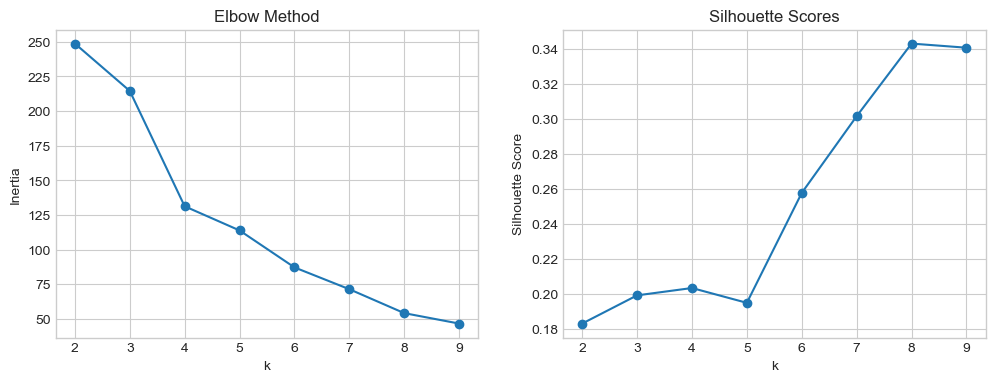

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []

K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(K, inertias, '-o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K, silhouettes, '-o')
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.savefig(OUTPUT_DIR / "kmeans_elbow_silhouette.png", dpi=300)

plt.show()


In [20]:
k_opt = 8

kmeans = KMeans(n_clusters=k_opt, random_state=42)
indicator_df["indicator_cluster"] = kmeans.fit_predict(X_scaled)


In [22]:
indicator_df.columns

Index(['indicator_name', 'spike_count', 'dip_count', 'avg_volatility',
       'slope_mean', 'momentum_mean', 'coef_variation', 'cagr_mean',
       'regional_dev_std', 'global_event_count', 'country_event_count',
       'category', 'PC1', 'PC2', 'indicator_cluster'],
      dtype='object')

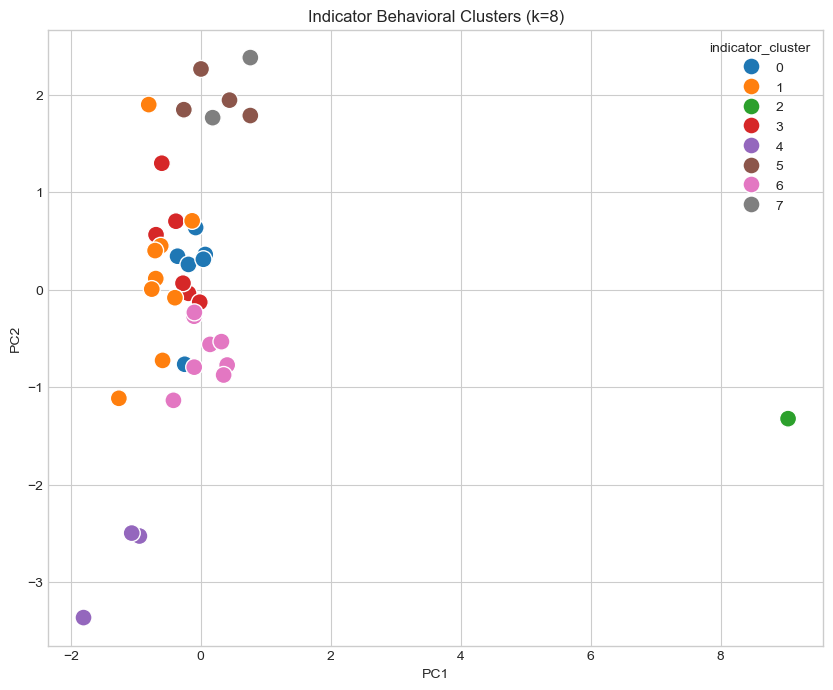

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=indicator_df,
    x="PC1", y="PC2",
    hue="indicator_cluster",
    palette="tab10",
    s=150
)

plt.title("Indicator Behavioral Clusters (k=8)")
plt.savefig(OUTPUT_DIR / "indicator_clusters_pca.png", dpi=300)
plt.show()


In [23]:
for c in sorted(indicator_df["indicator_cluster"].unique()):
    print(f"\n=== Cluster {c} ===")
    display(indicator_df[indicator_df["indicator_cluster"] == c][[
        "indicator_name",
        "spike_count",
        "dip_count",
        "avg_volatility",
        "slope_mean",
        "momentum_mean",
        "coef_variation",
        "cagr_mean"
    ]])



=== Cluster 0 ===


,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean
1,"A woman can be ""head of household"" in the same...",0,4,1.728872,0.014300,0.000000,73.882191,0.279537
15,"Birth rate, crude (per 1,000 people)",3,4,0.759607,-0.287333,0.000427,12.730975,-1.235273
18,"Employment to population ratio, 15+, female (%...",6,9,0.807638,0.119726,0.000825,14.044180,0.045901
19,"Employment to population ratio, 15+, male (%) ...",1,10,1.139124,-0.030374,0.000851,4.610323,-0.286762
22,"Life expectancy at birth, female (years)",4,6,0.557430,0.203007,-0.000306,2.344758,0.393315
23,"Life expectancy at birth, male (years)",5,8,0.754742,0.191064,-0.000372,2.987420,0.373807



=== Cluster 1 ===


,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean
21,"Inflation, consumer prices (annual %)",22,5,2.685478,0.385457,-0.002532,99.377651,0.790851
27,Proportion of women in ministerial level posit...,19,1,357.770519,219.683571,0.000000,57.220715,-2.542074
28,"School enrollment, secondary (gross), gender p...",12,6,8121.110346,3016.353403,-0.000149,48.834178,-1.028268
31,"Vulnerable employment, female (% of female emp...",10,3,1.150716,-0.379884,0.000904,36.369416,-0.872529
33,Women Business and the Law Index Score (scale ...,20,5,1.588495,0.762817,0.001701,17.941287,1.238996
35,"Women, Business and the Law: Entrepreneurship ...",13,4,0.754043,0.324275,0.000000,4.433503,0.209888
36,"Women, Business and the Law: Marriage Indicato...",14,4,1.989272,1.017391,0.000000,73.189023,0.279537
37,"Women, Business and the Law: Mobility Indicato...",14,1,2.068364,0.900362,0.000000,72.789761,2.208578
39,"Women, Business and the Law: Pay Indicator Sco...",17,4,2.323102,1.051329,0.000000,58.312127,0.386707



=== Cluster 2 ===


...

,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean
20,GDP per capita (current US$),6,4,2007.616110,340.764034,-0.000346,32.995139,4.557337
26,Proportion of seats held by women in national ...,6,6,357.494865,219.972633,0.000000,63.205247,3.892528
38,"Women, Business and the Law: Parenthood Indica...",7,9,1.728872,0.838164,0.000000,101.357159,1.625981
41,"Women, Business and the Law: Workplace Indicat...",11,7,3.506892,1.794082,0.000000,97.929192,3.574715



=== Cluster 6 ===


,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean
2,A woman can choose where to live in the same w...,7,0,1.728872,0.003164,0.000000,62.335208,0.279537
3,A woman can get a job in the same way as a man...,4,0,1.728872,0.001932,0.000000,25.379566,0.279537
4,A woman can obtain a judgment of divorce in th...,0,0,1.728872,0.000000,0.000000,0.000000,0.279537
5,A woman can open a bank account in the same wa...,0,0,1.728872,0.000000,0.000000,0.000000,0.279537
6,A woman can register a business in the same wa...,0,0,1.728872,0.000000,0.000000,0.000000,0.279537
7,A woman can sign a contract in the same way as...,0,0,1.728872,0.000000,0.000000,0.000000,0.279537
9,A woman can travel outside the country in the ...,7,1,1.728872,0.003720,0.000000,47.271052,0.279537
13,A woman has the same rights to remarry as a ma...,0,0,1.728872,0.000000,0.000000,32.995139,0.279537
32,"Vulnerable employment, male (% of male employm...",7,1,0.680879,-0.142198,0.000084,24.256874,-1.648076
34,"Women, Business and the Law: Assets Indicator ...",0,0,0.000000,0.000000,0.000000,0.000000,0.000000



=== Cluster 7 ===


,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean
29,"Unemployment, female (% of female labor force)...",5,4,1.255752,0.291838,-0.004480,24.566254,2.488678
30,"Unemployment, male (% of male labor force) (mo...",12,2,0.794121,0.000012,-0.005577,25.212277,0.452341


In [24]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=num_cols
)
loadings


,PC1,PC2
spike_count,-0.295615,0.040443
dip_count,-0.104059,0.440518
avg_volatility,0.620315,-0.131023
slope_mean,0.620360,-0.131429
momentum_mean,-0.137004,-0.558836
coef_variation,-0.121958,0.333469
cagr_mean,0.313850,0.588531


In [25]:
cluster_names = {
    0: "Gradual Structural Demographic",
    1: "Highly Volatile, Reform-Sensitive",
    2: "Outlier: Population Dynamics",
    3: "Stable Legal Rights",
    4: "Declining Health & Fertility",
    5: "Growing Participation & Economic",
    6: "Fully Stabilized Rights",
    7: "Labor Market Stress & Unemployment"
}

In [26]:
indicator_df["cluster_name"] = indicator_df["indicator_cluster"].map(cluster_names)

In [28]:
summary_table = (
    indicator_df
    .groupby(["indicator_cluster", "cluster_name"])
    .agg({
        "indicator_name": lambda x: list(x),
        "spike_count": "mean",
        "dip_count": "mean",
        "avg_volatility": "mean",
        "slope_mean": "mean",
        "cagr_mean": "mean",
        "momentum_mean": "mean",
        "coef_variation": "mean",
    })
    .reset_index()
)

summary_table
summary_table.to_csv(OUTPUT_DIR / "indicator_cluster_summary.csv", index=False)


In [29]:
def pretty_list(lst):
    return "\n".join(["• " + i for i in lst])

summary_table["indicator_list"] = summary_table["indicator_name"].apply(pretty_list)

summary_table_display = summary_table[[
    "cluster_name", 
    "indicator_list",
    "spike_count", 
    "dip_count", 
    "avg_volatility",
    "slope_mean",
    "cagr_mean",
    "momentum_mean",
    "coef_variation"
]]

summary_table_display


,cluster_name,indicator_list,spike_count,dip_count,avg_volatility,slope_mean,cagr_mean,momentum_mean,coef_variation
0,Gradual Structural Demographic,"• A woman can be ""head of household"" in the sa...",3.166667,6.833333,0.957902,0.035065,-0.071579,0.000238,18.433308
1,"Highly Volatile, Reform-Sensitive","• Inflation, consumer prices (annual %)\n• Pro...",15.666667,3.666667,943.493371,360.010969,0.074632,-0.000008,52.051962
2,Outlier: Population Dynamics,"• Population, total",0.000000,0.000000,707395.433593,451740.410676,3.037064,-0.000058,19.448991
3,Stable Legal Rights,• A woman can apply for a passport in the same...,7.666667,1.333333,1.728872,0.012927,0.279537,0.000000,128.279850
4,Declining Health & Fertility,"• Adolescent fertility rate (births per 1,000 ...",14.000000,0.666667,2.091453,-0.645944,-2.682624,0.003826,24.796514
5,Growing Participation & Economic,• GDP per capita (current US$)\n• Proportion o...,7.500000,6.500000,592.586685,140.842228,3.412640,-0.000087,73.871684
6,Fully Stabilized Rights,• A woman can choose where to live in the same...,2.909091,0.181818,1.477897,0.003959,0.026816,0.000008,19.237955
7,Labor Market Stress & Unemployment,"• Unemployment, female (% of female labor forc...",8.500000,3.000000,1.024937,0.145925,1.470510,-0.005029,24.889266


In [30]:
summary_table_display.to_csv(OUTPUT_DIR / "indicator_cluster_summary_pretty.csv", index=False)

In [31]:
indicator_df.to_csv("data/indicator_clusters.csv", index=False)